In [61]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/CMD_2024_Original.csv')
data

,NtAcceptConnectPort,NtAccessCheck,NtAccessCheckAndAuditAlarm,NtAccessCheckByType,NtAccessCheckByTypeAndAuditAlarm,NtAddAtom,NtAdjustGroupsToken,NtAdjustPrivilegesToken,NtAlertThread,NtAllocateLocallyUniqueId,...,Digital Sign,PE32/PE64,BL Import,Import,Export,BL Resource,Resource,BL String,String,Label
0,6,1824,143,71,54,19,1,24,137,0,...,1,0,48,76,0,0,6,23,4423,adware
1,1,1760,132,50,32,4,2,19,79,0,...,0,0,0,1,0,0,1,0,796,adware
2,6,1817,139,78,65,19,1,25,85,0,...,1,0,30,155,0,0,10,2,367,adware
3,1,1605,53,30,30,4,2,16,76,0,...,0,0,0,1,0,0,1,0,795,adware
4,6,1683,60,66,63,19,1,23,82,0,...,0,0,48,122,0,0,8,0,711,adware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20855,2,509,18,56,54,2,1,26,82,0,...,0,0,20,63,0,0,16,0,168,no malware
20856,3,574,42,67,60,4,1,25,90,0,...,0,0,62,130,0,0,1,0,1873,no malware
20857,0,460,39,59,55,0,1,18,65,0,...,0,0,4,331,0,0,29,0,328,no malware
20858,2,626,26,68,68,5,3,24,89,2,...,1,1,66,100,4,0,4,0,4253,no malware


In [62]:
data['Label'].value_counts()

Label
trojan        7484
no malware    5016
virus         3955
worm          2673
adware         800
ransomware     751
miner           90
pua             49
downloader      32
hacktool         7
banker           2
spyware          1
Name: count, dtype: int64

In [63]:
data.isna().sum()

NtAcceptConnectPort                 0
NtAccessCheck                       0
NtAccessCheckAndAuditAlarm          0
NtAccessCheckByType                 0
NtAccessCheckByTypeAndAuditAlarm    0
                                   ..
BL Resource                         0
Resource                            0
BL String                           0
String                              0
Label                               0
Length: 240, dtype: int64

In [64]:
multi_class_mapping = {
    'no malware': 0,        # Kelas 0
    'virus': 1,         # Kelas 1
    'trojan': 2,        # Kelas 2
    'worm': 3,          # Kelas 3
    'ransomware': 4,    # Kelas 4
    'adware': 5,        # Kelas 5
    'miner': 6,         # Kelas 6
    'pua': 7,           # Kelas 7
    'downloader': 8     # Kelas 8
}


In [65]:
# Membuat kolom baru yang berisi ID multi-class yang sudah diubah
data['Label'] = data['Label'].map(multi_class_mapping)
data['Label'].value_counts()

Label
2.0    7484
0.0    5016
1.0    3955
3.0    2673
5.0     800
4.0     751
6.0      90
7.0      49
8.0      32
Name: count, dtype: int64

In [66]:
print("Sebelum drop NaN:")
print(f"Jumlah data: {len(data)}")
print(data['Label'].value_counts(dropna=False))

data = data.dropna(subset=['Label'])

print("\nSetelah drop NaN:")
print(f"Jumlah data: {len(data)}")
print(data['Label'].value_counts())

Sebelum drop NaN:
Jumlah data: 20860
Label
2.0    7484
0.0    5016
1.0    3955
3.0    2673
5.0     800
4.0     751
6.0      90
7.0      49
8.0      32
NaN      10
Name: count, dtype: int64

Setelah drop NaN:
Jumlah data: 20850
Label
2.0    7484
0.0    5016
1.0    3955
3.0    2673
5.0     800
4.0     751
6.0      90
7.0      49
8.0      32
Name: count, dtype: int64


In [67]:
# Grouping berdasarkan tipe data
with pd.option_context('display.max_rows', None):
    print(data.dtypes)

NtAcceptConnectPort                   int64
NtAccessCheck                         int64
NtAccessCheckAndAuditAlarm            int64
NtAccessCheckByType                   int64
NtAccessCheckByTypeAndAuditAlarm      int64
NtAddAtom                             int64
NtAdjustGroupsToken                   int64
NtAdjustPrivilegesToken               int64
NtAlertThread                         int64
NtAllocateLocallyUniqueId             int64
NtAllocateUuids                       int64
NtAllocateVirtualMemory               int64
NtAlpcAcceptConnectPort               int64
NtAlpcConnectPort                     int64
NtAlpcCreatePort                      int64
NtAlpcCreatePortSection               int64
NtAlpcCreateResourceReserve           int64
NtAlpcCreateSectionView               int64
NtAlpcCreateSecurityContext           int64
NtAlpcDeletePortSection               int64
NtAlpcDeleteSectionView               int64
NtAlpcDeleteSecurityContext           int64
NtAlpcDisconnectPort            

In [68]:
data['MD5'].value_counts()

MD5
003e58934b7b89c5a8ad8a84dc33e190    1
00fc198ea600776311f4bc6f9d9f4f20    1
0240f9d785a3ceda43a71161a5c3dfb7    1
01dd9079a101d25659d53f930baf4eb0    1
e2dff6dc1a7b8a272a153a56e47bd172    1
                                   ..
a4d55bb65b35a4e0cc980d3bf3f9a3a2    1
526b18dca68e4a7a38eb846bbffabca8    1
290a89759f954fb694dbf180170148ed    1
3ea5f1c56f187d7a4827e7a5db1d90f2    1
1605c115e9f7c954639f1ac61d7c3520    1
Name: count, Length: 20850, dtype: int64

In [69]:
ft = ['MD5','SHA1','SHA256']
data = data.drop(columns=ft)

In [70]:
# Grouping berdasarkan tipe data
with pd.option_context('display.max_rows', None):
    print(data.dtypes)

NtAcceptConnectPort                   int64
NtAccessCheck                         int64
NtAccessCheckAndAuditAlarm            int64
NtAccessCheckByType                   int64
NtAccessCheckByTypeAndAuditAlarm      int64
NtAddAtom                             int64
NtAdjustGroupsToken                   int64
NtAdjustPrivilegesToken               int64
NtAlertThread                         int64
NtAllocateLocallyUniqueId             int64
NtAllocateUuids                       int64
NtAllocateVirtualMemory               int64
NtAlpcAcceptConnectPort               int64
NtAlpcConnectPort                     int64
NtAlpcCreatePort                      int64
NtAlpcCreatePortSection               int64
NtAlpcCreateResourceReserve           int64
NtAlpcCreateSectionView               int64
NtAlpcCreateSecurityContext           int64
NtAlpcDeletePortSection               int64
NtAlpcDeleteSectionView               int64
NtAlpcDeleteSecurityContext           int64
NtAlpcDisconnectPort            

In [71]:
data['Label'].value_counts()

# ✅ Ambil class_labels langsung dari kolom
class_labels = sorted(data['Label'].unique().tolist())
class_labels

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

In [72]:
from sklearn.model_selection import train_test_split

X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (16680, 236)
Shape of X_test: (4170, 236)
Shape of y_train: (16680,)
Shape of y_test: (4170,)


In [73]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,f1_score, classification_report

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time


# ── Helper ──────────────────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, training_time=None, testing_time=None):
    print(f"\n{'='*50}")
    print(f"  {name} Results")
    print(f"{'='*50}")
    if training_time is not None:
        print(f"  Training Time : {training_time:.4f}s")
    if testing_time is not None:
        print(f"  Testing Time  : {testing_time:.4f}s")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Precision Macro : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall Macro   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score Macro : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=[str(x) for x in class_labels], zero_division=0))

# 1. Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
y_pred_rf = rf_model.predict(X_test)
rf_test_time = time.time() - start

print_metrics("Random Forest", y_test, y_pred_rf, training_time=rf_time, testing_time=rf_test_time)

# 2. XGBoost Classifier
print("\n--- Training XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    random_state=42
)
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

start = time.time()
y_pred_xgb = xgb_model.predict(X_test)
xgb_test_time = time.time() - start

print_metrics("XGBoost", y_test, y_pred_xgb, training_time=xgb_time, testing_time=xgb_test_time)

# 3. LightGBM Classifier
print("\n--- Training LightGBM Classifier ---")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=None,
    learning_rate=0.2,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
start = time.time()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - start

start = time.time()
y_pred_lgbm = lgbm_model.predict(X_test)
lgbm_test_time = time.time() - start

print_metrics("LightGBM", y_test, y_pred_lgbm, training_time=lgbm_time, testing_time=lgbm_test_time)


--- Training Random Forest Classifier ---

  Random Forest Results
  Training Time : 14.4739s
  Testing Time  : 0.1121s
  Accuracy  : 0.8928
  Precision : 0.8905
  Precision Macro : 0.7521
  Recall    : 0.8928
  Recall Macro   : 0.6770
  F1-Score  : 0.8898
  F1-Score Macro : 0.7019

  Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      1003
         1.0       0.87      0.88      0.87       791
         2.0       0.86      0.92      0.89      1497
         3.0       0.92      0.82      0.87       535
         4.0       0.98      0.91      0.94       150
         5.0       0.81      0.54      0.65       160
         6.0       0.89      0.89      0.89        18
         7.0       0.00      0.00      0.00        10
         8.0       0.50      0.17      0.25         6

    accuracy                           0.89      4170
   macro avg       0.75      0.68      0.70      4170
weighted avg       0.89      0.89      

In [75]:
# ── Rekap Perbandingan Semua Model ─────────────────────────────────────────
import pandas as pd

def collect_metrics(name, y_true, y_pred, train_time=None, test_time=None):
    return {
        "Model"              : name,
        "F1 Macro"           : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        "F1 Weighted"        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall Macro"       : recall_score(y_true, y_pred, average='macro',    zero_division=0),
        "Recall Weighted"    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision Macro"    : precision_score(y_true, y_pred, average='macro',    zero_division=0),
        "Precision Weighted" : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Accuracy"           : accuracy_score(y_true, y_pred),
        "Train Time (s)"     : round(train_time, 4) if train_time is not None else None,
        "Test Time (s)"      : round(test_time, 4) if test_time is not None else None,
    }

results = [
    collect_metrics("Random Forest", y_test, y_pred_rf,   rf_time,   rf_test_time),
    collect_metrics("XGBoost",       y_test, y_pred_xgb,  xgb_time,  xgb_test_time),
    collect_metrics("LightGBM",      y_test, y_pred_lgbm, lgbm_time, lgbm_test_time),
]

df_recap = pd.DataFrame(results).set_index("Model")

# Format 4 desimal untuk semua kolom numerik
fmt_cols = ["F1 Macro", "F1 Weighted", "Recall Macro", "Recall Weighted",
            "Precision Macro", "Precision Weighted", "Accuracy"]
df_display = df_recap.copy()
df_display[fmt_cols] = df_display[fmt_cols].map(lambda x: f"{x:.4f}")

# ── Tampilkan rekap ────────────────────────────────────────────────────────
print("\n" + "="*80)
print("  REKAP PERBANDINGAN MODEL")
print("="*80)

# Urutkan berdasarkan F1 Macro (descending)
df_sorted = df_recap.sort_values("F1 Macro", ascending=False)

metric_order = [
    ("F1 Macro",           "F1-Score Macro   "),
    ("F1 Weighted",        "F1-Score Weighted"),
    ("Recall Macro",       "Recall Macro     "),
    ("Recall Weighted",    "Recall Weighted  "),
    ("Precision Macro",    "Precision Macro  "),
    ("Precision Weighted", "Precision Weighted"),
    ("Accuracy",           "Accuracy         "),
]

for col, label in metric_order:
    print(f"\n  Ranking — {label.strip()}")
    print(f"  {'-'*40}")
    ranked = df_recap[col].sort_values(ascending=False)
    for rank, (model, val) in enumerate(ranked.items(), 1):
        marker = " ✓ TERBAIK" if rank == 1 else ""
        print(f"  {rank}. {model:<20} {val:.4f}{marker}")

# ── Tabel ringkasan lengkap ────────────────────────────────────────────────
print("\n" + "="*80)
print("  TABEL RINGKASAN LENGKAP")
print("="*80)
print(df_display.to_string())

# ── Model terbaik per metrik ───────────────────────────────────────────────
print("\n" + "="*80)
print("  MODEL TERBAIK PER METRIK")
print("="*80)
for col, label in metric_order:
    best_model = df_recap[col].idxmax()
    best_val   = df_recap[col].max()
    print(f"  {label.strip():<22} → {best_model:<20} ({best_val:.4f})")
print("="*80)


  REKAP PERBANDINGAN MODEL

  Ranking — F1-Score Macro
  ----------------------------------------
  1. LightGBM             0.7937 ✓ TERBAIK
  2. XGBoost              0.7678
  3. Random Forest        0.7019

  Ranking — F1-Score Weighted
  ----------------------------------------
  1. LightGBM             0.9307 ✓ TERBAIK
  2. XGBoost              0.9285
  3. Random Forest        0.8898

  Ranking — Recall Macro
  ----------------------------------------
  1. LightGBM             0.7606 ✓ TERBAIK
  2. XGBoost              0.7380
  3. Random Forest        0.6770

  Ranking — Recall Weighted
  ----------------------------------------
  1. LightGBM             0.9317 ✓ TERBAIK
  2. XGBoost              0.9300
  3. Random Forest        0.8928

  Ranking — Precision Macro
  ----------------------------------------
  1. LightGBM             0.8758 ✓ TERBAIK
  2. XGBoost              0.8417
  3. Random Forest        0.7521

  Ranking — Precision Weighted
  -----------------------------------


--- SHAP Analysis: XGBoost ---


<Figure size 640x480 with 0 Axes>

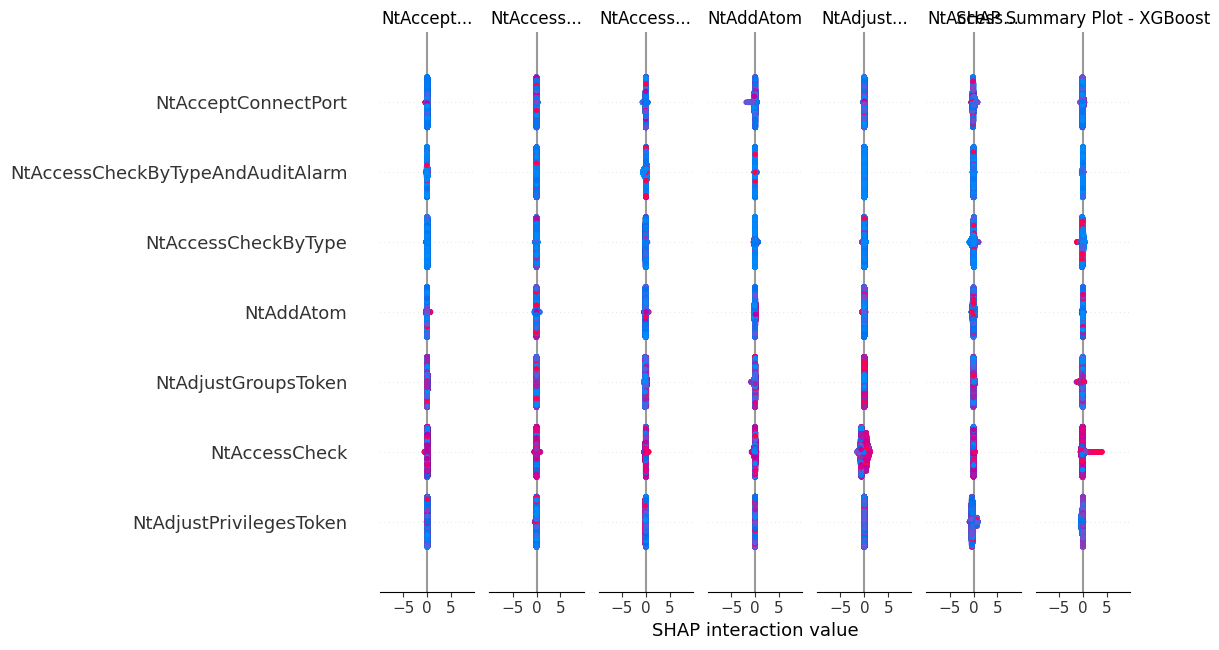

In [76]:
import shap
import matplotlib.pyplot as plt
import numpy as np
# ── 2. SHAP untuk XGBoost ────────────────────────────────────
print("\n--- SHAP Analysis: XGBoost ---")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

plt.figure()
shap.summary_plot(
    shap_values_xgb, X_train,
    class_names=class_labels,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost")
plt.tight_layout()
plt.savefig("shap_xgb_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# ── SHAP dari X_train, bukan X_test ──────────────────────────
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)  # ✅ ganti ke X_train

if shap_values_xgb.ndim == 3:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=(0, 2))
else:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=0)

shap_xgb_df = pd.DataFrame({
    'Feature'        : X_train.columns,  # ✅ ganti ke X_train
    'SHAP_Importance': shap_xgb_mean
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
print("\nTop 20 Features (XGBoost - SHAP):")
print(shap_xgb_df.head(20).to_string(index=False))



Top 20 Features (XGBoost - SHAP):
                 Feature  SHAP_Importance
                Resource         0.503469
                  Import         0.498586
                  String         0.491815
               BL Import         0.461085
            Digital Sign         0.360365
            NtSetTimerEx         0.229460
      NtPowerInformation         0.221464
               PE32/PE64         0.183216
        NtCallbackReturn         0.178931
NtQueryInformationThread         0.145825
               BL String         0.140471
             NtWriteFile         0.122515
              NtFindAtom         0.121527
                  Export         0.116888
            NtOpenMutant         0.109703
  NtReplyWaitReceivePort         0.101645
           NtQueryObject         0.098868
              NtReadFile         0.092901
     NtReadVirtualMemory         0.092259
 NtFlushInstructionCache         0.091992


In [78]:
import numpy as np
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import classification_report
import pandas as pd

# ── 1. Definisi persentil & SMOTE variants ───────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]
from sklearn.preprocessing import MinMaxScaler

smote_variants = {
    # 'SMOTE'           : SMOTE(random_state=42),
    # 'SMOTEENN'        : SMOTEENN(random_state=42),
    'SMOTETomek'      : SMOTETomek(random_state=42),
    # 'BorderlineSMOTE' : BorderlineSMOTE(random_state=42)
}

# ── 2. Loop persentil × SMOTE ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    # Hitung N fitur
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    # Ambil fitur
    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"{'='*60}")

    for smote_name, sampler in smote_variants.items():
        print(f"\n  [{smote_name}]")

        # Resample X_train
        X_res, y_res = sampler.fit_resample(X_train_p, y_train)
        print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
        
        # Normaliszation
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        # Retrain model
        xgb_ps = XGBClassifier(**xgb_model.get_params())
        xgb_ps.fit(X_train_scaled, y_res)

        # Evaluasi di test asli (tidak di-resample)
        y_pred = xgb_ps.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred))

        # Simpan hasil
        key = f'P{P}_{smote_name}'
        results_all[key] = {
            'Persentil'   : P,
            'N Fitur'     : N_FEATURES,
            'SMOTE'       : smote_name,
            'Accuracy'    : report['accuracy'],
            'F1 Macro'    : report['macro avg']['f1-score'],
            'F1 Weighted' : report['weighted avg']['f1-score'],
            'Precision'   : report['macro avg']['precision'],
            'Recall'      : report['macro avg']['recall'],
        }

# ── 3. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 4. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   SMOTE     : {best['SMOTE']}")
print(f"   F1 Macro  : {best['F1 Macro']}")


  Persentil P=10% → 24 fitur

  [SMOTETomek]
  Shape train : (16680, 24) → (53163, 24)
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      1003
         1.0       0.91      0.92      0.92       791
         2.0       0.92      0.91      0.92      1497
         3.0       0.91      0.88      0.89       535
         4.0       0.97      0.97      0.97       150
         5.0       0.77      0.80      0.78       160
         6.0       0.85      0.94      0.89        18
         7.0       0.67      0.60      0.63        10
         8.0       0.33      0.33      0.33         6

    accuracy                           0.92      4170
   macro avg       0.81      0.82      0.81      4170
weighted avg       0.92      0.92      0.92      4170


  Persentil P=20% → 48 fitur

  [SMOTETomek]
  Shape train : (16680, 48) → (53157, 48)
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      1003
         1

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd

# ── 1. Definisi persentil & model ───────────────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.2,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=None,
        learning_rate=0.2,
        class_weight='balanced',
        random_state=42,
        verbose = -1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    )
}

sampler = SMOTETomek(random_state=42)


  Persentil P=10% → 24 fitur
  Shape train : (16680, 24) → (53163, 24)

  [XGBoost]
  Training Time : 5.4729s
  Testing Time  : 0.0216s
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      1003
         1.0       0.91      0.92      0.92       791
         2.0       0.92      0.91      0.92      1497
         3.0       0.91      0.88      0.89       535
         4.0       0.97      0.97      0.97       150
         5.0       0.77      0.80      0.78       160
         6.0       0.85      0.94      0.89        18
         7.0       0.67      0.60      0.63        10
         8.0       0.33      0.33      0.33         6

    accuracy                           0.92      4170
   macro avg       0.81      0.82      0.81      4170
weighted avg       0.92      0.92      0.92      4170



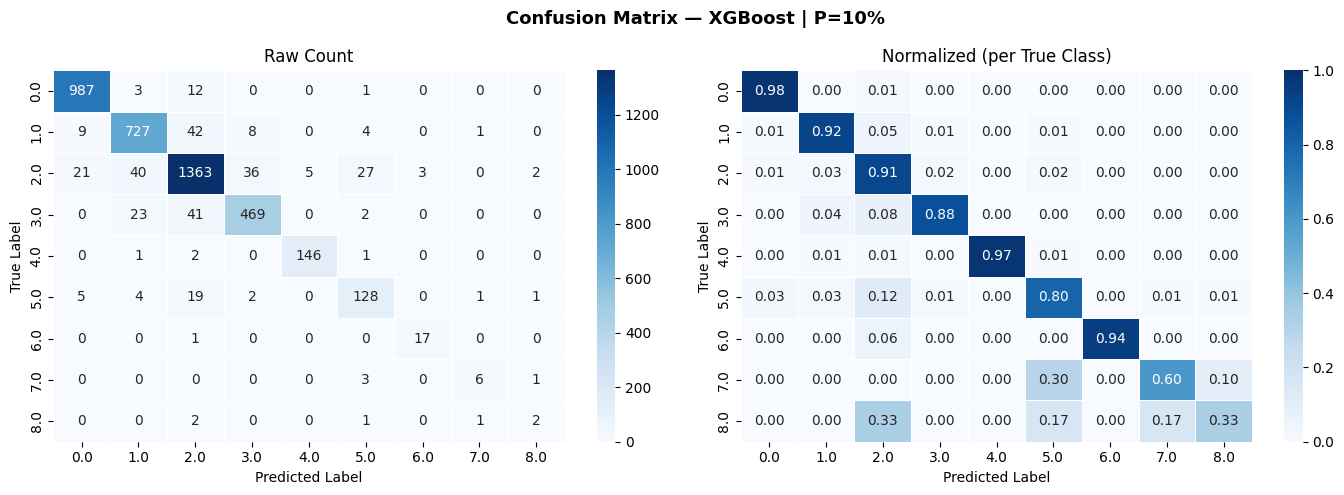


  [LightGBM]
  Training Time : 10.5985s
  Testing Time  : 0.0976s
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1003
         1.0       0.90      0.92      0.91       791
         2.0       0.92      0.92      0.92      1497
         3.0       0.93      0.87      0.90       535
         4.0       0.98      0.97      0.98       150
         5.0       0.75      0.79      0.77       160
         6.0       1.00      0.94      0.97        18
         7.0       0.71      0.50      0.59        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.92      4170
   macro avg       0.82      0.79      0.80      4170
weighted avg       0.92      0.92      0.92      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


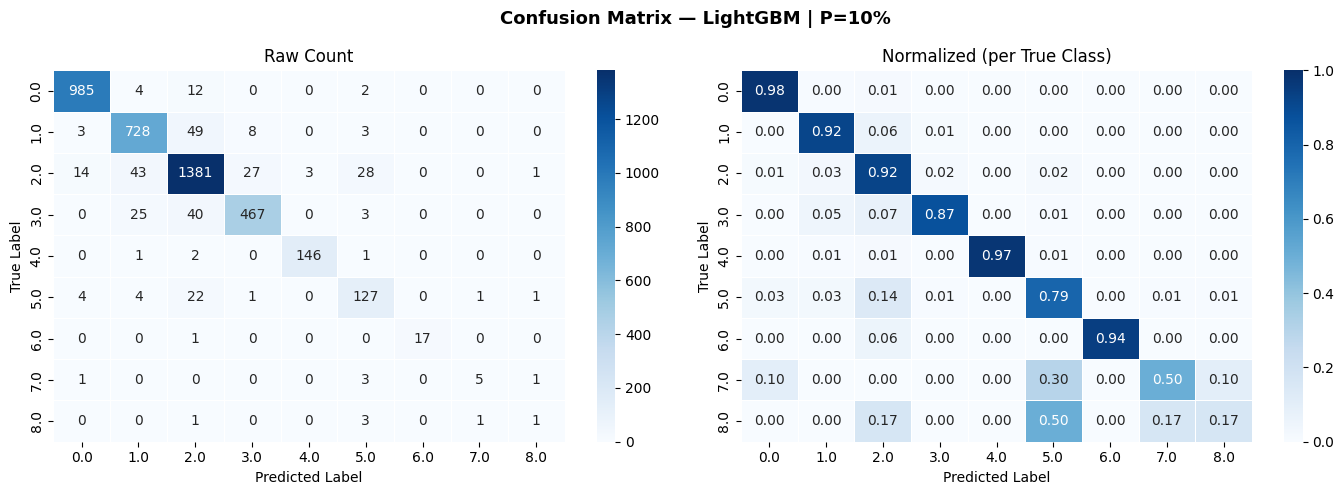


  [RandomForest]
  Training Time : 15.3358s
  Testing Time  : 0.1068s
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96      1003
         1.0       0.88      0.89      0.89       791
         2.0       0.91      0.89      0.90      1497
         3.0       0.91      0.86      0.88       535
         4.0       0.97      0.96      0.97       150
         5.0       0.71      0.75      0.73       160
         6.0       0.89      0.94      0.92        18
         7.0       0.56      0.50      0.53        10
         8.0       0.20      0.17      0.18         6

    accuracy                           0.90      4170
   macro avg       0.77      0.77      0.77      4170
weighted avg       0.90      0.90      0.90      4170



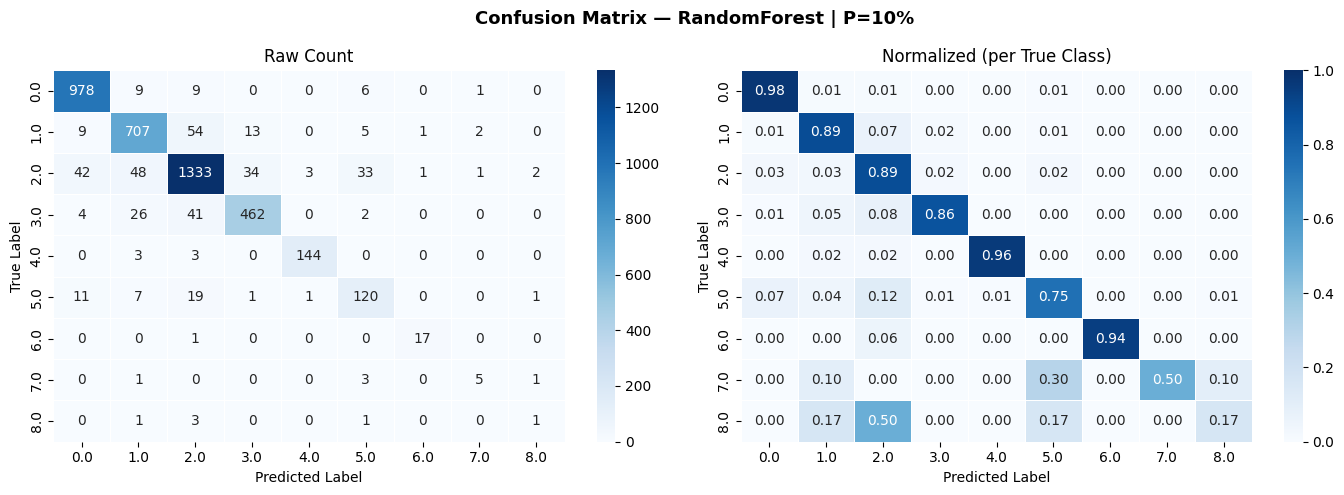


  Persentil P=20% → 48 fitur
  Shape train : (16680, 48) → (53157, 48)

  [XGBoost]
  Training Time : 6.9395s
  Testing Time  : 0.0202s
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      1003
         1.0       0.90      0.91      0.91       791
         2.0       0.92      0.92      0.92      1497
         3.0       0.92      0.87      0.90       535
         4.0       0.98      0.96      0.97       150
         5.0       0.77      0.77      0.77       160
         6.0       0.95      1.00      0.97        18
         7.0       0.56      0.50      0.53        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.92      4170
   macro avg       0.80      0.79      0.79      4170
weighted avg       0.92      0.92      0.92      4170



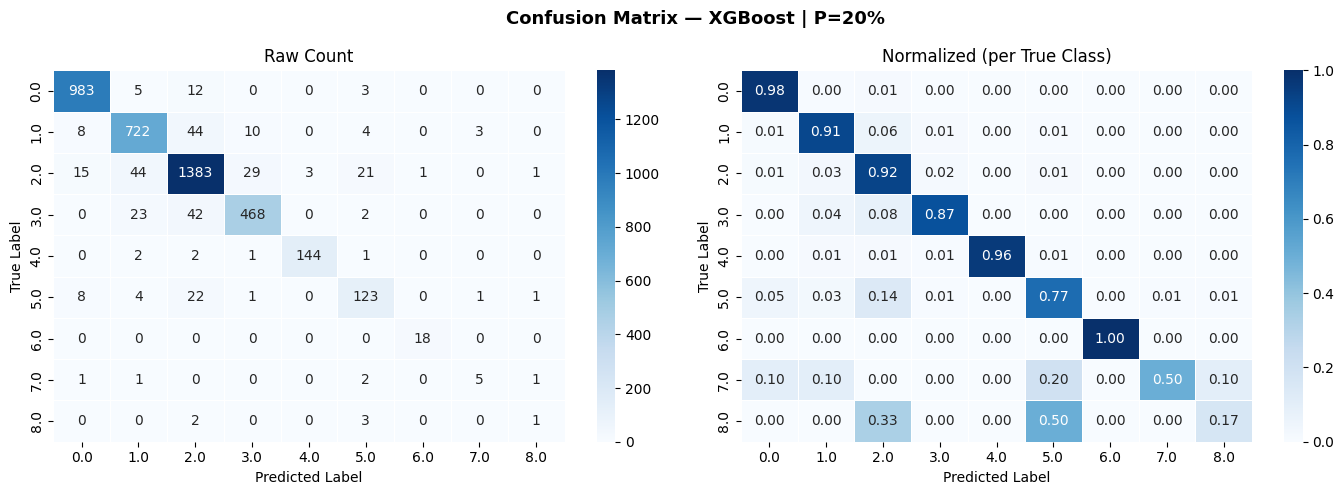


  [LightGBM]
  Training Time : 11.8952s
  Testing Time  : 0.1067s
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      1003
         1.0       0.91      0.91      0.91       791
         2.0       0.91      0.92      0.92      1497
         3.0       0.92      0.88      0.90       535
         4.0       0.97      0.96      0.96       150
         5.0       0.79      0.74      0.77       160
         6.0       0.94      0.94      0.94        18
         7.0       0.71      0.50      0.59        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.92      4170
   macro avg       0.82      0.78      0.80      4170
weighted avg       0.92      0.92      0.92      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


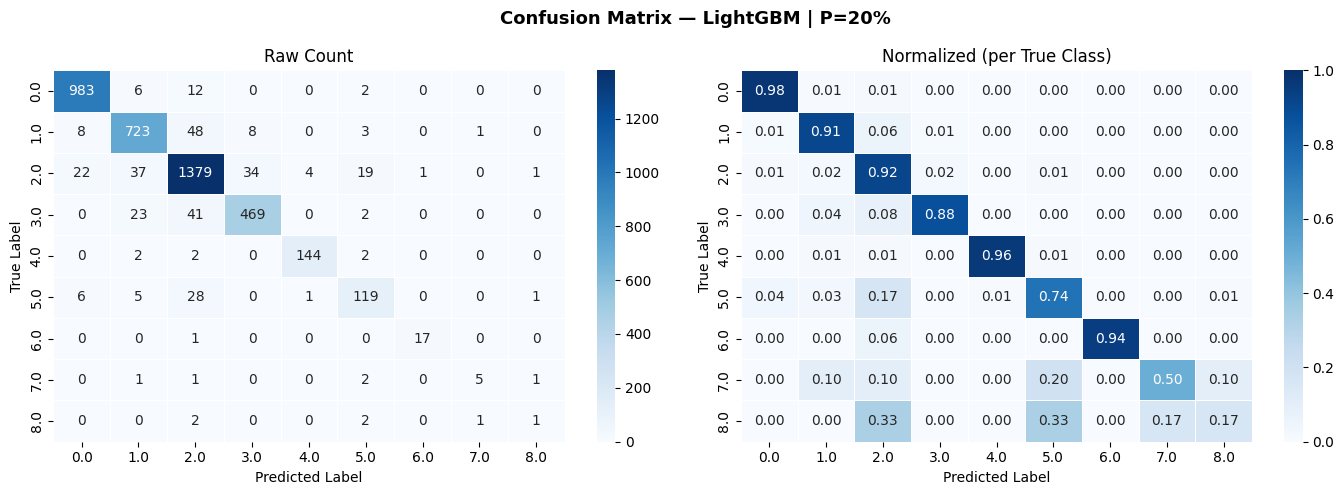


  [RandomForest]
  Training Time : 22.7784s
  Testing Time  : 0.1040s
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96      1003
         1.0       0.89      0.90      0.89       791
         2.0       0.91      0.89      0.90      1497
         3.0       0.90      0.88      0.89       535
         4.0       0.97      0.97      0.97       150
         5.0       0.70      0.72      0.71       160
         6.0       0.90      1.00      0.95        18
         7.0       0.56      0.50      0.53        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.90      4170
   macro avg       0.78      0.78      0.78      4170
weighted avg       0.90      0.90      0.90      4170



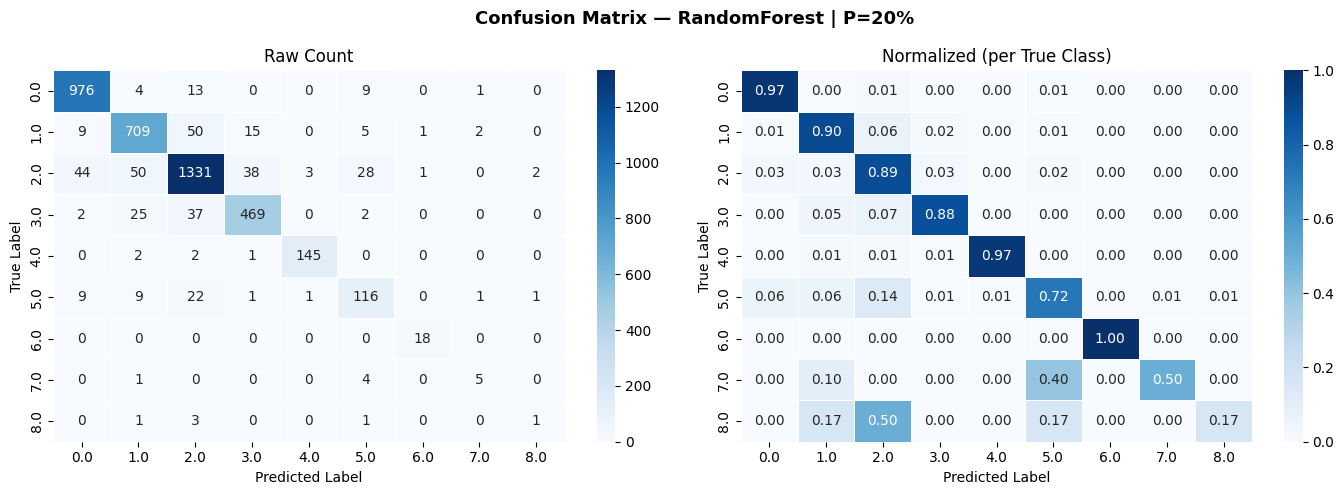


  Persentil P=30% → 71 fitur
  Shape train : (16680, 71) → (53245, 71)

  [XGBoost]
  Training Time : 8.0392s
  Testing Time  : 0.0197s
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1003
         1.0       0.91      0.91      0.91       791
         2.0       0.92      0.93      0.92      1497
         3.0       0.91      0.89      0.90       535
         4.0       0.98      0.96      0.97       150
         5.0       0.81      0.77      0.79       160
         6.0       0.95      1.00      0.97        18
         7.0       0.67      0.60      0.63        10
         8.0       0.17      0.17      0.17         6

    accuracy                           0.93      4170
   macro avg       0.81      0.80      0.80      4170
weighted avg       0.93      0.93      0.93      4170



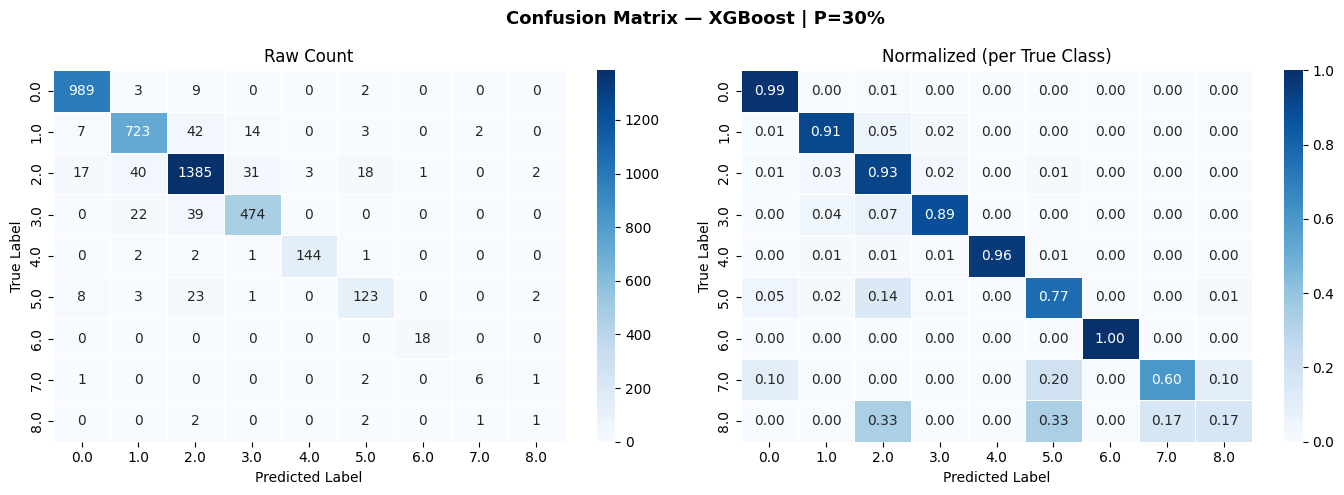


  [LightGBM]
  Training Time : 13.1529s
  Testing Time  : 0.1062s
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1003
         1.0       0.92      0.92      0.92       791
         2.0       0.92      0.93      0.93      1497
         3.0       0.92      0.89      0.90       535
         4.0       0.98      0.96      0.97       150
         5.0       0.78      0.72      0.75       160
         6.0       1.00      0.94      0.97        18
         7.0       0.56      0.50      0.53        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.93      4170
   macro avg       0.82      0.78      0.80      4170
weighted avg       0.93      0.93      0.93      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


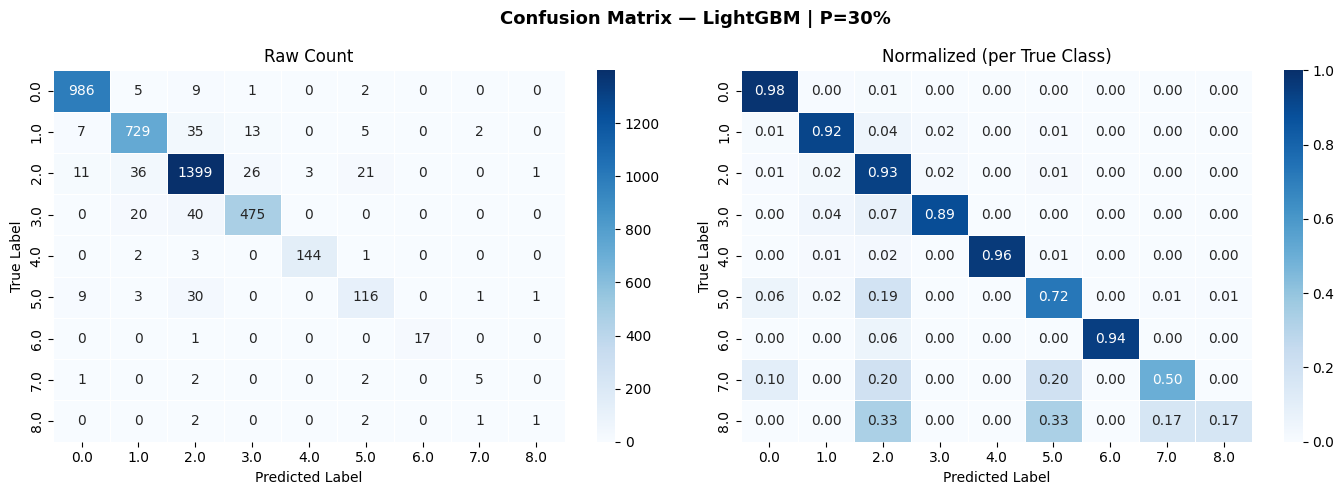


  [RandomForest]
  Training Time : 28.9760s
  Testing Time  : 0.1073s
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1003
         1.0       0.88      0.90      0.89       791
         2.0       0.91      0.88      0.90      1497
         3.0       0.89      0.87      0.88       535
         4.0       0.97      0.95      0.96       150
         5.0       0.73      0.74      0.74       160
         6.0       0.86      1.00      0.92        18
         7.0       0.50      0.40      0.44        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.90      4170
   macro avg       0.78      0.77      0.77      4170
weighted avg       0.90      0.90      0.90      4170



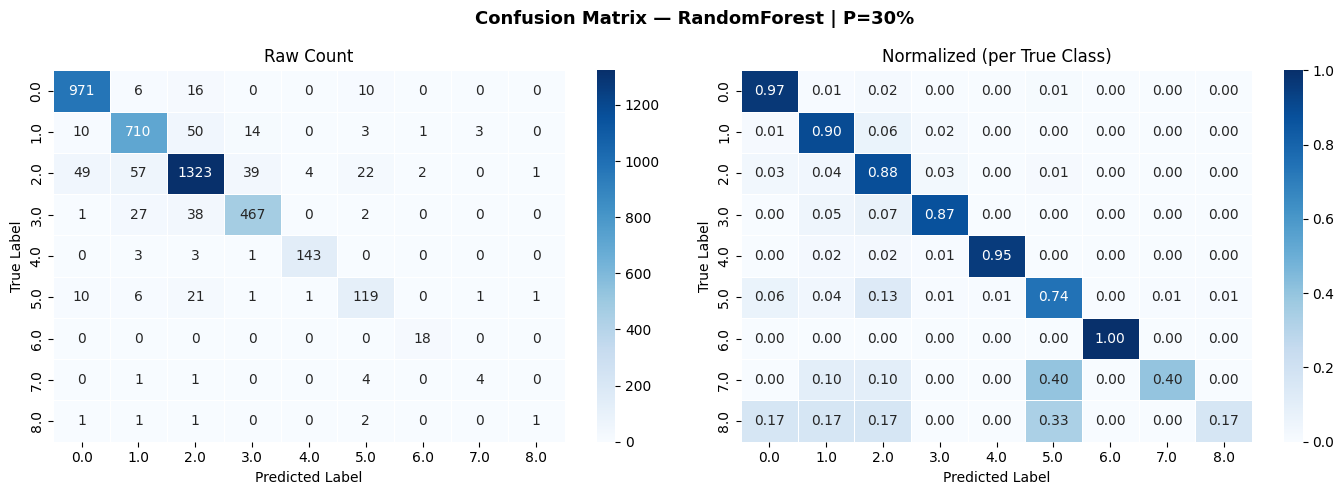


  Persentil P=40% → 95 fitur
  Shape train : (16680, 95) → (53205, 95)

  [XGBoost]
  Training Time : 10.1225s
  Testing Time  : 0.0189s
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1003
         1.0       0.91      0.91      0.91       791
         2.0       0.92      0.92      0.92      1497
         3.0       0.91      0.88      0.90       535
         4.0       0.97      0.95      0.96       150
         5.0       0.79      0.78      0.78       160
         6.0       0.95      1.00      0.97        18
         7.0       0.44      0.40      0.42        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.92      4170
   macro avg       0.79      0.78      0.78      4170
weighted avg       0.92      0.92      0.92      4170



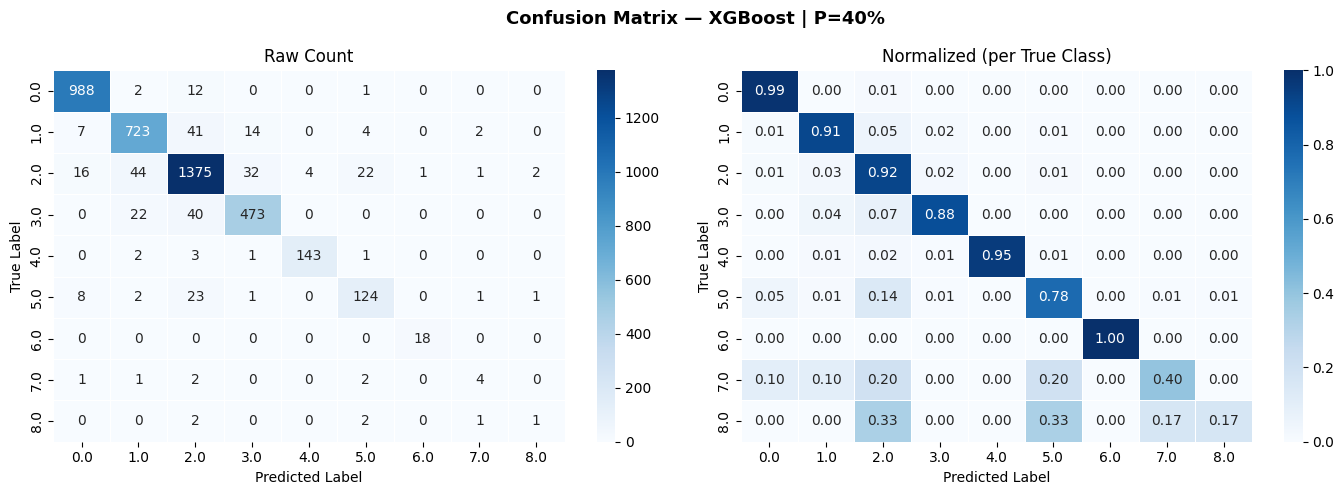


  [LightGBM]
  Training Time : 14.9792s
  Testing Time  : 0.1152s
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1003
         1.0       0.91      0.92      0.91       791
         2.0       0.92      0.93      0.92      1497
         3.0       0.91      0.88      0.90       535
         4.0       0.98      0.96      0.97       150
         5.0       0.79      0.72      0.76       160
         6.0       0.94      0.94      0.94        18
         7.0       0.57      0.40      0.47        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.93      4170
   macro avg       0.81      0.77      0.79      4170
weighted avg       0.92      0.93      0.92      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


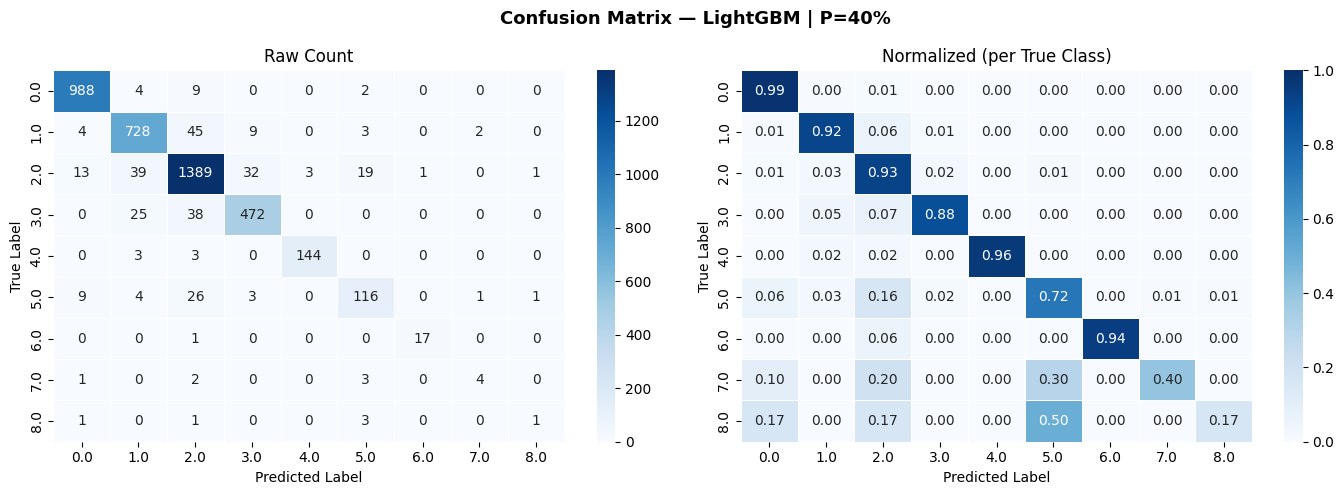


  [RandomForest]
  Training Time : 33.1002s
  Testing Time  : 0.1097s
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1003
         1.0       0.88      0.90      0.89       791
         2.0       0.91      0.88      0.89      1497
         3.0       0.90      0.87      0.89       535
         4.0       0.97      0.95      0.96       150
         5.0       0.70      0.68      0.69       160
         6.0       0.86      1.00      0.92        18
         7.0       0.38      0.30      0.33        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.90      4170
   macro avg       0.75      0.75      0.75      4170
weighted avg       0.90      0.90      0.90      4170



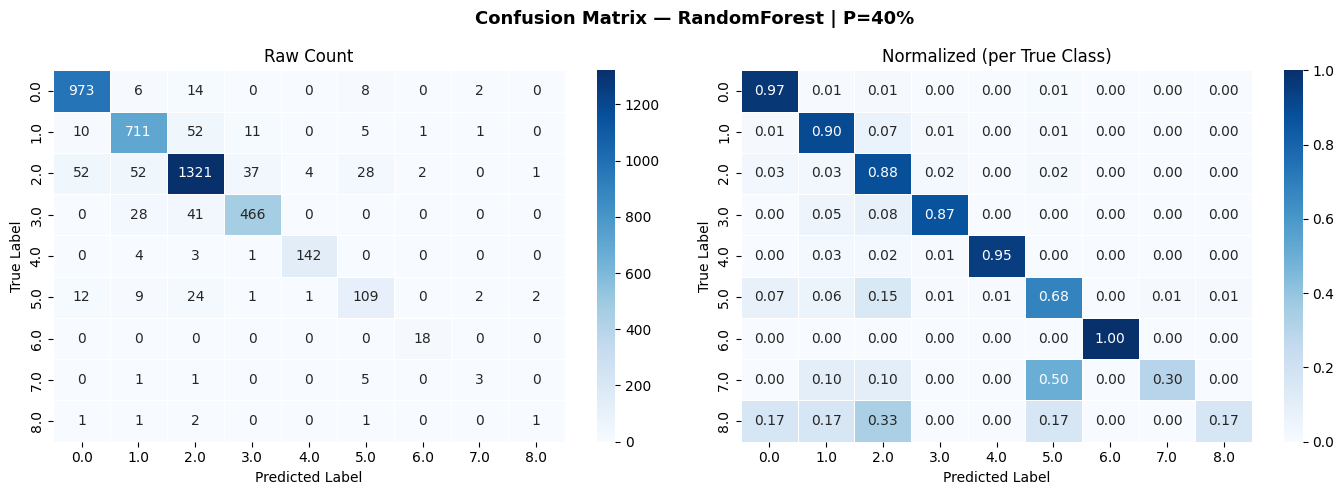


  Persentil P=50% → 118 fitur
  Shape train : (16680, 118) → (53189, 118)

  [XGBoost]
  Training Time : 11.9431s
  Testing Time  : 0.0200s
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1003
         1.0       0.91      0.92      0.91       791
         2.0       0.92      0.92      0.92      1497
         3.0       0.91      0.88      0.89       535
         4.0       0.98      0.95      0.97       150
         5.0       0.78      0.79      0.78       160
         6.0       0.90      1.00      0.95        18
         7.0       0.55      0.60      0.57        10
         8.0       0.50      0.33      0.40         6

    accuracy                           0.92      4170
   macro avg       0.82      0.82      0.82      4170
weighted avg       0.92      0.92      0.92      4170



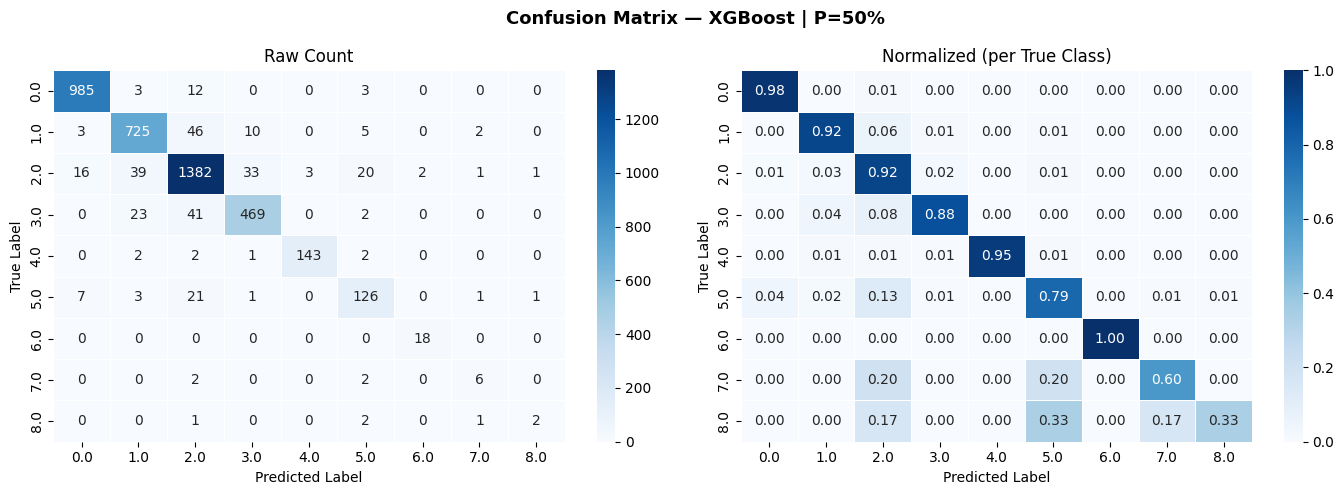


  [LightGBM]
  Training Time : 19.5262s
  Testing Time  : 0.1207s
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      1003
         1.0       0.90      0.92      0.91       791
         2.0       0.92      0.93      0.93      1497
         3.0       0.92      0.87      0.90       535
         4.0       0.98      0.97      0.97       150
         5.0       0.80      0.74      0.77       160
         6.0       0.95      1.00      0.97        18
         7.0       0.56      0.50      0.53        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.93      4170
   macro avg       0.82      0.79      0.80      4170
weighted avg       0.93      0.93      0.93      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


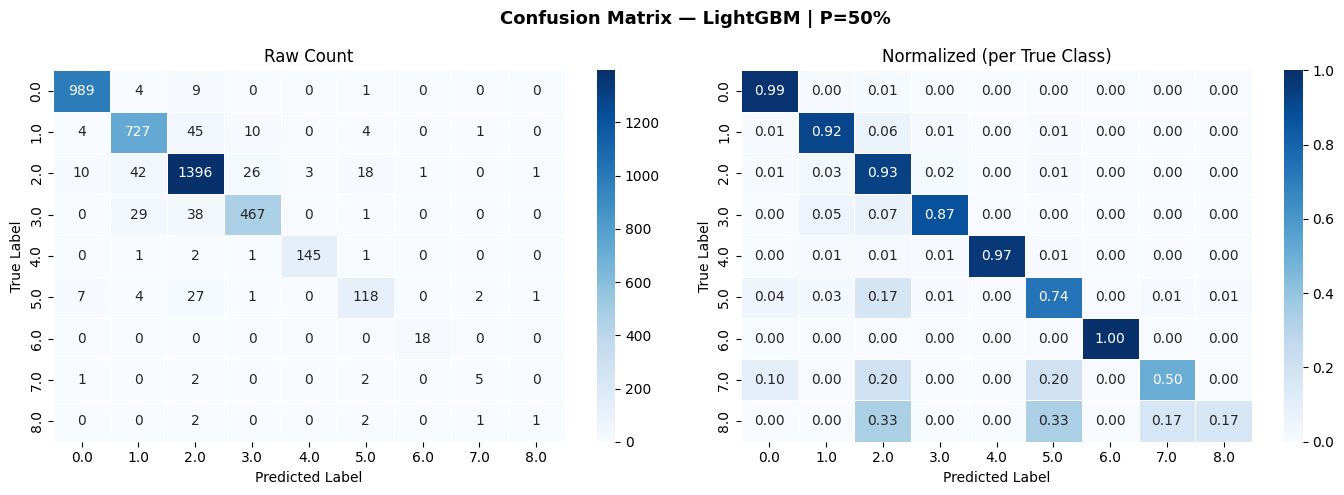


  [RandomForest]
  Training Time : 36.9074s
  Testing Time  : 0.1058s
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94      1003
         1.0       0.86      0.89      0.88       791
         2.0       0.91      0.88      0.89      1497
         3.0       0.89      0.87      0.88       535
         4.0       0.97      0.93      0.95       150
         5.0       0.72      0.68      0.70       160
         6.0       0.82      1.00      0.90        18
         7.0       0.38      0.30      0.33        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.89      4170
   macro avg       0.75      0.74      0.74      4170
weighted avg       0.89      0.89      0.89      4170



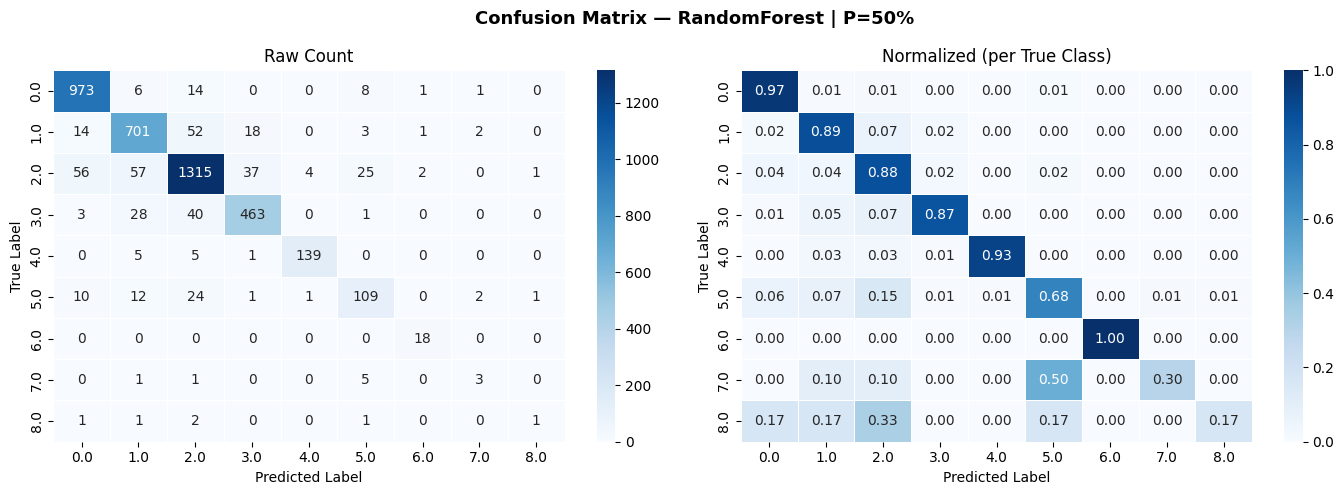


  Persentil P=60% → 142 fitur
  Shape train : (16680, 142) → (53181, 142)

  [XGBoost]
  Training Time : 13.4071s
  Testing Time  : 0.0204s
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1003
         1.0       0.91      0.92      0.91       791
         2.0       0.92      0.93      0.92      1497
         3.0       0.91      0.88      0.89       535
         4.0       0.97      0.95      0.96       150
         5.0       0.81      0.77      0.79       160
         6.0       0.90      1.00      0.95        18
         7.0       0.44      0.40      0.42        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.92      4170
   macro avg       0.79      0.78      0.78      4170
weighted avg       0.92      0.92      0.92      4170



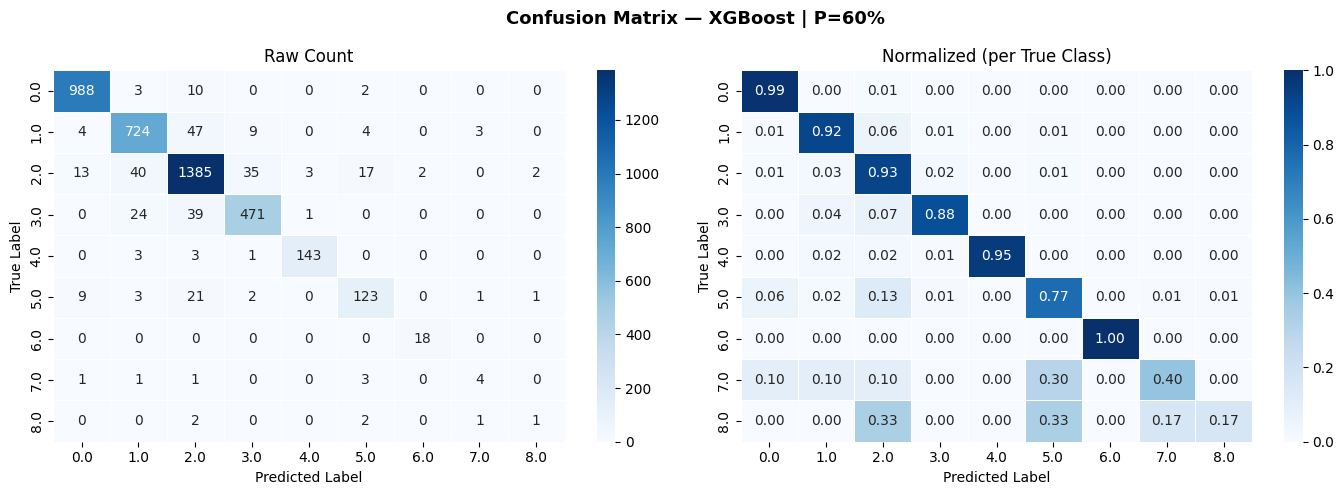


  [LightGBM]
  Training Time : 17.8633s
  Testing Time  : 0.1172s
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      1003
         1.0       0.91      0.92      0.91       791
         2.0       0.92      0.93      0.92      1497
         3.0       0.92      0.89      0.90       535
         4.0       0.97      0.96      0.97       150
         5.0       0.81      0.76      0.78       160
         6.0       0.94      0.94      0.94        18
         7.0       0.57      0.40      0.47        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.93      4170
   macro avg       0.82      0.77      0.79      4170
weighted avg       0.93      0.93      0.93      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


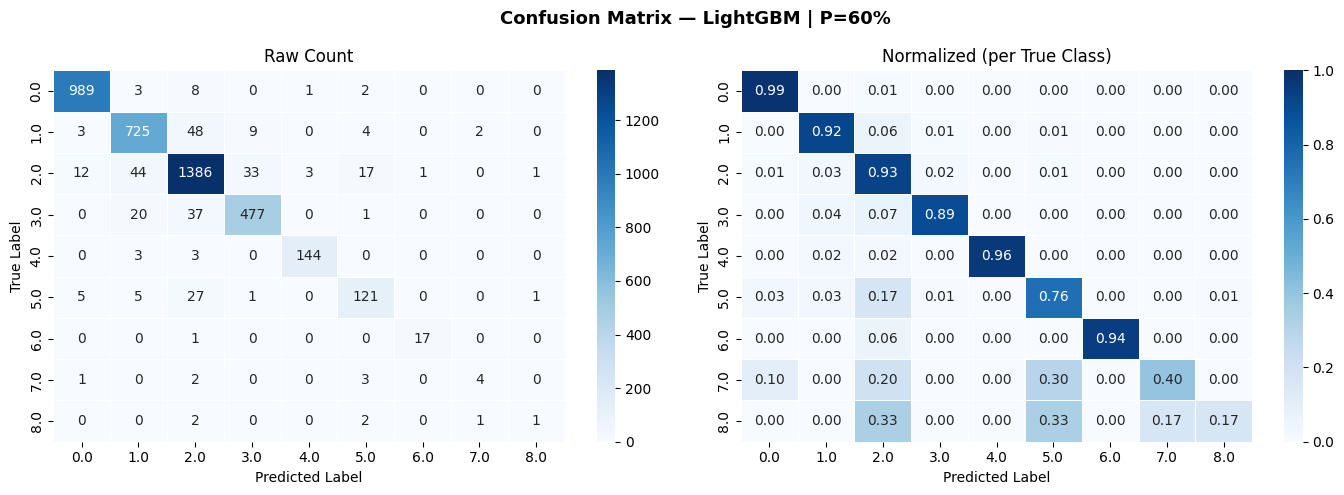


  [RandomForest]
  Training Time : 40.8962s
  Testing Time  : 0.1114s
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      1003
         1.0       0.87      0.89      0.88       791
         2.0       0.90      0.88      0.89      1497
         3.0       0.89      0.86      0.88       535
         4.0       0.97      0.95      0.96       150
         5.0       0.72      0.65      0.68       160
         6.0       0.82      1.00      0.90        18
         7.0       0.44      0.40      0.42        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.89      4170
   macro avg       0.76      0.75      0.75      4170
weighted avg       0.89      0.89      0.89      4170



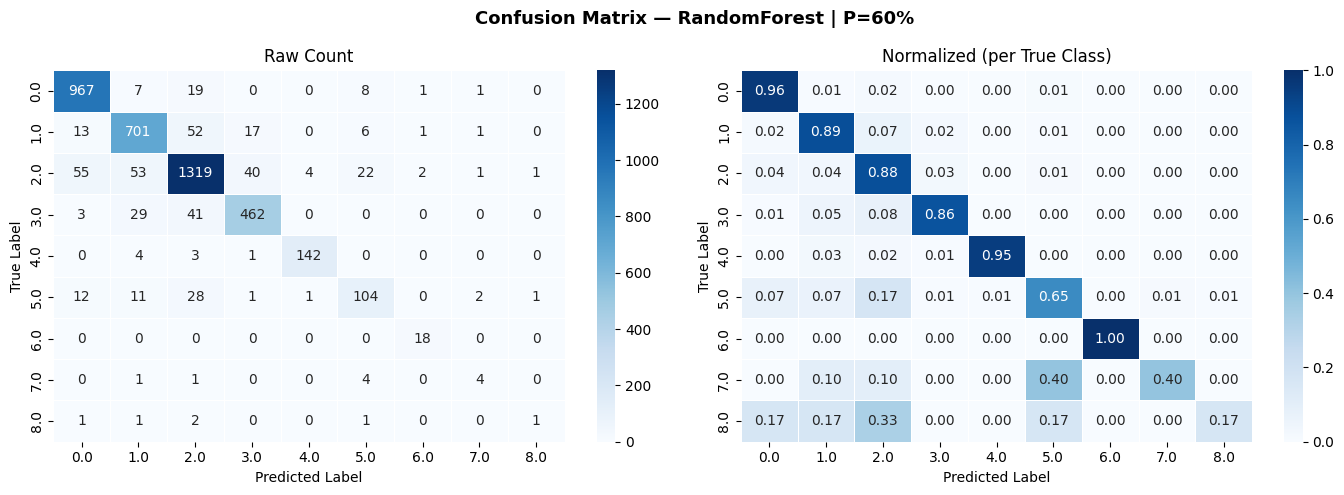


  Persentil P=70% → 166 fitur
  Shape train : (16680, 166) → (53185, 166)

  [XGBoost]
  Training Time : 14.1021s
  Testing Time  : 0.0186s
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      1003
         1.0       0.91      0.92      0.91       791
         2.0       0.92      0.93      0.92      1497
         3.0       0.90      0.88      0.89       535
         4.0       0.97      0.95      0.96       150
         5.0       0.83      0.74      0.78       160
         6.0       0.86      1.00      0.92        18
         7.0       0.57      0.40      0.47        10
         8.0       0.25      0.17      0.20         6

    accuracy                           0.92      4170
   macro avg       0.80      0.77      0.78      4170
weighted avg       0.92      0.92      0.92      4170



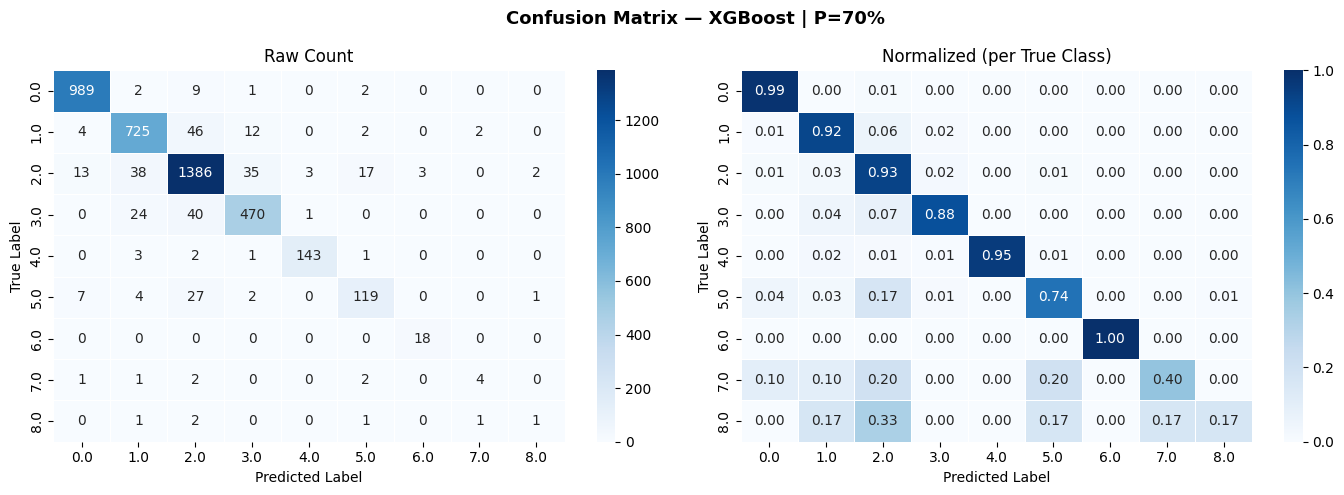


  [LightGBM]
  Training Time : 19.2547s
  Testing Time  : 0.1130s
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1003
         1.0       0.90      0.92      0.91       791
         2.0       0.92      0.92      0.92      1497
         3.0       0.91      0.88      0.89       535
         4.0       0.98      0.96      0.97       150
         5.0       0.80      0.77      0.79       160
         6.0       0.94      0.94      0.94        18
         7.0       0.50      0.30      0.38        10
         8.0       0.33      0.17      0.22         6

    accuracy                           0.93      4170
   macro avg       0.81      0.76      0.78      4170
weighted avg       0.92      0.93      0.92      4170



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


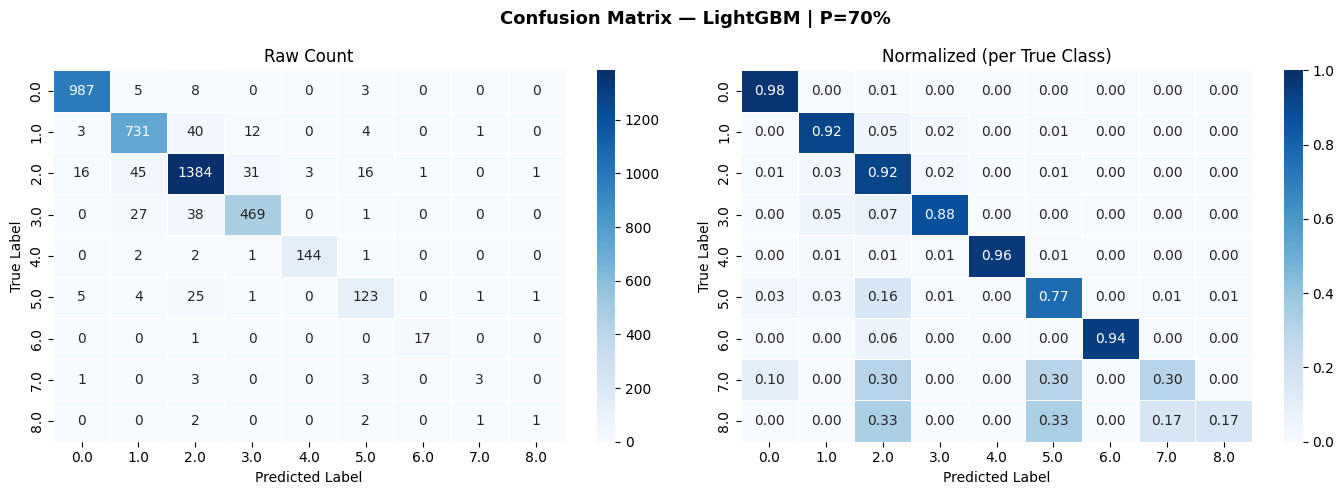


  [RandomForest]
  Training Time : 41.4981s
  Testing Time  : 0.1113s
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94      1003
         1.0       0.87      0.89      0.88       791
         2.0       0.90      0.88      0.89      1497
         3.0       0.90      0.85      0.88       535
         4.0       0.97      0.94      0.95       150
         5.0       0.70      0.64      0.67       160
         6.0       0.86      1.00      0.92        18
         7.0       0.33      0.30      0.32        10
         8.0       0.17      0.17      0.17         6

    accuracy                           0.89      4170
   macro avg       0.73      0.74      0.73      4170
weighted avg       0.89      0.89      0.89      4170



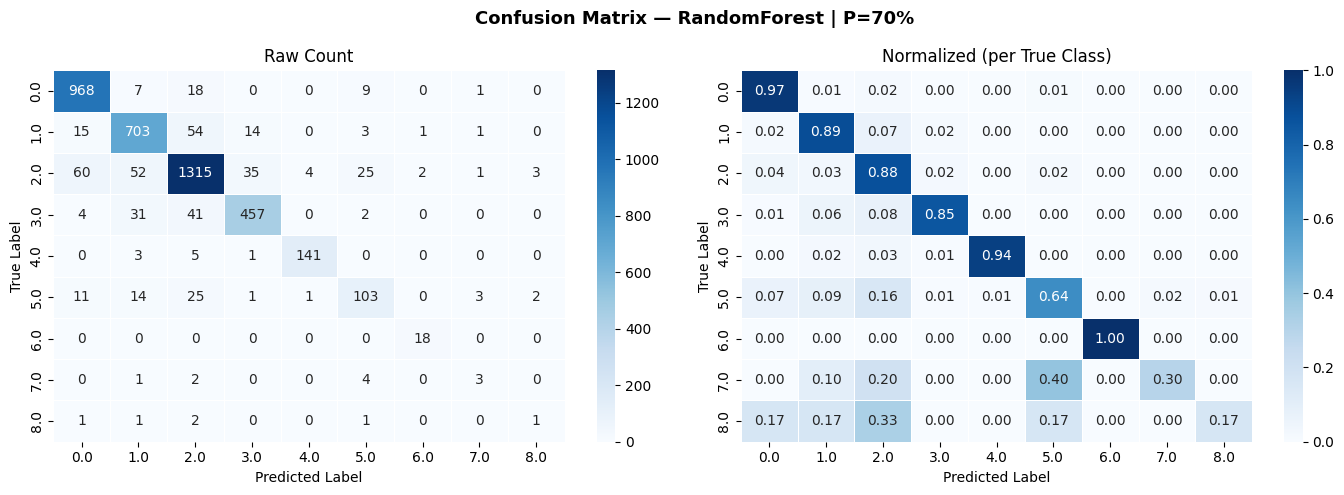


── Perbandingan Semua Kombinasi (SMOTETomek) ──
                 Persentil N Fitur         Model  Accuracy  F1 Macro F1 Weighted Precision Macro Precision Weighted Recall Macro Recall Weighted Training Time Testing Time
P50_XGBoost             50     118       XGBoost    0.9247  0.819368    0.924548        0.824269           0.924596     0.819177          0.9247       11.9431         0.02
P10_XGBoost             10      24       XGBoost  0.922062  0.812321    0.921949        0.810058           0.922042     0.815708        0.922062        5.4729       0.0216
P30_XGBoost             30      71       XGBoost  0.926379  0.804772    0.926049        0.809577           0.925877      0.80074        0.926379        8.0392       0.0197
P10_LightGBM            10      24      LightGBM   0.92494  0.801919    0.924749        0.824214           0.924992     0.786223         0.92494       10.5985       0.0976
P50_LightGBM            50     118      LightGBM  0.927098  0.797622    0.926437        0.8

In [80]:
# ── 2. Helper plot confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, percentile, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name} | P={percentile}%', fontsize=13, fontweight='bold')

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

# ── 3. Loop persentil × model ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    X_res, y_res = sampler.fit_resample(X_train_p, y_train)

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
    print(f"{'='*60}")

    for model_name, clf in models.items():
        print(f"\n  [{model_name}]")

        clf_fit = clf.__class__(**clf.get_params())

        # Normalization
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        start = time.time()
        clf_fit.fit(X_train_scaled, y_res)
        train_time = time.time() - start
        print(f"  Training Time : {train_time:.4f}s")

        # ── Testing Time ────────────────────────────────────────────────────
        start = time.time()
        y_pred = clf_fit.predict(X_test_scaled)
        test_time = time.time() - start
        print(f"  Testing Time  : {test_time:.4f}s")

        report = classification_report(y_test, y_pred, output_dict=True)
        print(classification_report(y_test, y_pred, target_names=[str(x) for x in class_labels]))

        # ── Confusion Matrix ────────────────────────────────────────────────
        plot_confusion_matrix(y_test, y_pred, model_name, P, class_labels)

        key = f'P{P}_{model_name}'
        results_all[key] = {
            'Persentil'          : P,
            'N Fitur'            : N_FEATURES,
            'Model'              : model_name,
            'Accuracy'           : report['accuracy'],
            'F1 Macro'           : report['macro avg']['f1-score'],
            'F1 Weighted'        : report['weighted avg']['f1-score'],
            'Precision Macro'    : report['macro avg']['precision'],
            'Precision Weighted' : report['weighted avg']['precision'],
            'Recall Macro'       : report['macro avg']['recall'],
            'Recall Weighted'    : report['weighted avg']['recall'],
            'Training Time'      : round(train_time, 4),
            'Testing Time'       : round(test_time, 4),
        }

# ── 4. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi (SMOTETomek) ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 5. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Model     : {best['Model']}")
print(f"   F1 Macro  : {best['F1 Macro']}")